# Customer Churn & Retention Intelligence System

## Phase 6 — Retention Intelligence and Scoring Pipeline

### Objective

The objective of this phase is to convert the trained churn model and customer-level features into a reusable scoring workflow.

The pipeline generates churn probabilities, customer risk segments, retention-priority categories, and basic recommended retention actions.

These outputs will later be used by the Flask prediction API and the Power BI dashboard.

In [1]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:.4f}"
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

MODEL_DIR = (
    PROJECT_ROOT / "models"
)

SRC_DIR = (
    PROJECT_ROOT / "src"
)

SRC_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed:", PROCESSED_DATA_DIR)
print("Models:", MODEL_DIR)
print("Source:", SRC_DIR)

Processed: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\data\processed
Models: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\models
Source: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\src


In [3]:
model = joblib.load(
    MODEL_DIR
    / "tuned_xgboost_churn_model.joblib"
)

model_features = (
    pd.read_csv(
        MODEL_DIR
        / "model_features.csv"
    )["Feature"]
    .tolist()
)

customer_features = pd.read_csv(
    PROCESSED_DATA_DIR
    / "customer_features.csv"
)

print(
    "Customer dataset shape:",
    customer_features.shape
)

print(
    "Model features:",
    len(model_features)
)

Customer dataset shape: (4979, 18)
Model features: 16


## Reusable Customer Scoring

The saved XGBoost model is used to generate churn probabilities for the complete customer feature dataset.

The scoring logic is kept separate from model training so that the same process can later be reused by the API and other applications.

In [4]:
#Generate probabilities
X_scoring = customer_features[
    model_features
].copy()

customer_scores = customer_features[
    ["Customer ID", "Churn"]
].copy()

customer_scores["ChurnProbability"] = (
    model.predict_proba(
        X_scoring
    )[:, 1]
)

customer_scores.head()

,Customer ID,Churn,ChurnProbability
0,13085,0,0.2879
1,13078,0,0.0436
2,15362,1,0.6088
3,18102,0,0.0249
4,12682,0,0.0302


In [5]:
LOW_THRESHOLD = 0.2363
MEDIUM_THRESHOLD = 0.5217
HIGH_THRESHOLD = 0.7084

print(
    "Low / Medium threshold:",
    LOW_THRESHOLD
)

print(
    "Medium / High threshold:",
    MEDIUM_THRESHOLD
)

print(
    "High / Critical threshold:",
    HIGH_THRESHOLD
)


Low / Medium threshold: 0.2363
Medium / High threshold: 0.5217
High / Critical threshold: 0.7084


In [6]:
def assign_risk_segment(probability):

    if probability <= LOW_THRESHOLD:
        return "Low"

    elif probability <= MEDIUM_THRESHOLD:
        return "Medium"

    elif probability <= HIGH_THRESHOLD:
        return "High"

    else:
        return "Critical"

In [7]:
customer_scores["RiskSegment"] = (
    customer_scores[
        "ChurnProbability"
    ]
    .apply(assign_risk_segment)
)

customer_scores[
    "RiskSegment"
].value_counts()

RiskSegment
Medium      1245
Low         1245
Critical    1245
High        1244
Name: count, dtype: int64

In [8]:
customer_scores = (
    customer_scores
    .merge(
        customer_features[
            [
                "Customer ID",
                "RecencyDays",
                "PurchaseFrequency",
                "MonetaryValue",
                "UniqueProducts",
                "IsRepeatCustomer"
            ]
        ],
        on="Customer ID",
        how="left"
    )
)

customer_scores.head()

,Customer ID,Churn,ChurnProbability,RiskSegment,RecencyDays,PurchaseFrequency,MonetaryValue,UniqueProducts,IsRepeatCustomer
0,13085,0,0.2879,Medium,114.9535,7,2295.3000,46,1
1,13078,0,0.0436,Low,20.0285,41,20857.2800,131,1
2,15362,1,0.6088,High,268.0924,2,613.0800,38,1
3,18102,0,0.0249,Low,2.8076,102,413459.3700,310,1
4,12682,0,0.0302,Low,11.9708,32,15947.6900,251,1


In [9]:
HIGH_VALUE_THRESHOLD = 1960.30

customer_scores[
    "HighValueCustomer"
] = (
    customer_scores["MonetaryValue"]
    >= HIGH_VALUE_THRESHOLD
).astype(int)

print(
    customer_scores[
        "HighValueCustomer"
    ].value_counts()
)

HighValueCustomer
0    3734
1    1245
Name: count, dtype: int64


## Retention Recommendation Logic

Risk scores are translated into simple retention recommendations so that model outputs can support business action.

The recommendations are based on churn risk, historical customer value, purchase frequency, and recent inactivity.

They are intended as decision-support categories rather than automated marketing decisions.

In [10]:
def assign_retention_priority(row):

    if (
        row["RiskSegment"] == "Critical"
        and row["HighValueCustomer"] == 1
    ):
        return "Immediate Action"

    elif row["RiskSegment"] == "Critical":
        return "High Priority"

    elif (
        row["RiskSegment"] == "High"
        and row["HighValueCustomer"] == 1
    ):
        return "High Priority"

    elif row["RiskSegment"] == "High":
        return "Medium Priority"

    else:
        return "Monitor"

In [11]:
customer_scores[
    "RetentionPriority"
] = customer_scores.apply(
    assign_retention_priority,
    axis=1
)

customer_scores[
    "RetentionPriority"
].value_counts()

RetentionPriority
Monitor             2490
High Priority       1278
Medium Priority     1184
Immediate Action      27
Name: count, dtype: int64

In [12]:
def recommend_action(row):

    if row["RetentionPriority"] == "Immediate Action":
        return (
            "Personalised retention outreach "
            "with high-value incentive"
        )

    elif row["RetentionPriority"] == "High Priority":
        return (
            "Targeted re-engagement campaign "
            "with personalised offer"
        )

    elif row["RetentionPriority"] == "Medium Priority":
        return (
            "Automated re-engagement reminder "
            "or promotional campaign"
        )

    else:
        return (
            "Continue monitoring and regular "
            "customer engagement"
        )

In [13]:
customer_scores[
    "RecommendedAction"
] = customer_scores.apply(
    recommend_action,
    axis=1
)

customer_scores[
    [
        "Customer ID",
        "ChurnProbability",
        "RiskSegment",
        "RetentionPriority",
        "RecommendedAction"
    ]
].head(15)

,Customer ID,ChurnProbability,RiskSegment,RetentionPriority,RecommendedAction
0,13085,0.2879,Medium,Monitor,Continue monitoring and regular customer engag...
1,13078,0.0436,Low,Monitor,Continue monitoring and regular customer engag...
2,15362,0.6088,High,Medium Priority,Automated re-engagement reminder or promotiona...
3,18102,0.0249,Low,Monitor,Continue monitoring and regular customer engag...
4,12682,0.0302,Low,Monitor,Continue monitoring and regular customer engag...
5,18087,0.1680,Low,Monitor,Continue monitoring and regular customer engag...
6,13635,0.5049,Medium,Monitor,Continue monitoring and regular customer engag...
7,14110,0.0497,Low,Monitor,Continue monitoring and regular customer engag...
8,12636,0.9129,Critical,High Priority,Targeted re-engagement campaign with personali...
9,17519,0.0423,Low,Monitor,Continue monitoring and regular customer engag...


## Reusable Scoring Module

The churn scoring and retention-priority logic is moved into a reusable Python module.

This allows the same business rules to be used consistently by the notebook, Flask API, and future dashboard or batch-scoring workflows.

In [16]:
# Import reusable scoring module

import sys
import importlib
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import scoring module
import src.scoring

# Reload module in case scoring.py was edited
importlib.reload(src.scoring)

from src.scoring import score_single_customer

print("Single-customer scorer loaded successfully.")

Single-customer scorer loaded successfully.


In [18]:
from src.scoring import (
    score_customers,
    score_single_customer
)

print("Batch and single-customer scorers loaded successfully.")

Batch and single-customer scorers loaded successfully.


In [21]:
test_customer_id = 13085

test_customer = (
    customer_features[
        customer_features[
            "Customer ID"
        ]
        == test_customer_id
    ]
    .iloc[0]
)

test_features = (
    test_customer[
        model_features
    ]
    .to_dict()
)

single_result = (
    score_single_customer(
        model=model,
        customer_features=test_features,
        model_features=model_features
    )
)

print(
    "Customer ID:",
    test_customer_id
)

single_result

Customer ID: 13085


{'churn_probability': 0.2878907322883606,
 'risk_segment': 'Medium',
 'retention_priority': 'Monitor',
 'recommended_action': 'Continue monitoring and regular customer engagement'}

In [22]:
module_scores = score_customers(
    model=model,
    customer_data=customer_features.copy(),
    model_features=model_features
)

print(
    "Scored dataset shape:",
    module_scores.shape
)

module_scores[
    [
        "Customer ID",
        "ChurnProbability",
        "RiskSegment",
        "RetentionPriority",
        "RecommendedAction"
    ]
].head(10)

Scored dataset shape: (4979, 23)


,Customer ID,ChurnProbability,RiskSegment,RetentionPriority,RecommendedAction
0,13085,0.2879,Medium,Monitor,Continue monitoring and regular customer engag...
1,13078,0.0436,Low,Monitor,Continue monitoring and regular customer engag...
2,15362,0.6088,High,Medium Priority,Automated re-engagement reminder or promotiona...
3,18102,0.0249,Low,Monitor,Continue monitoring and regular customer engag...
4,12682,0.0302,Low,Monitor,Continue monitoring and regular customer engag...
5,18087,0.1680,Low,Monitor,Continue monitoring and regular customer engag...
6,13635,0.5049,Medium,Monitor,Continue monitoring and regular customer engag...
7,14110,0.0497,Low,Monitor,Continue monitoring and regular customer engag...
8,12636,0.9129,Critical,High Priority,Targeted re-engagement campaign with personali...
9,17519,0.0423,Low,Monitor,Continue monitoring and regular customer engag...


In [23]:
probability_match = np.allclose(
    customer_scores["ChurnProbability"].values,
    module_scores["ChurnProbability"].values
)

print(
    "Probability results match:",
    probability_match
)

Probability results match: True


In [24]:
risk_match = (
    customer_scores["RiskSegment"]
    .astype(str)
    .values
    ==
    module_scores["RiskSegment"]
    .astype(str)
    .values
).all()

print(
    "Risk segments match:",
    risk_match
)

Risk segments match: True


In [25]:
priority_match = (
    customer_scores["RetentionPriority"]
    .astype(str)
    .values
    ==
    module_scores["RetentionPriority"]
    .astype(str)
    .values
).all()

print(
    "Retention priorities match:",
    priority_match
)

Retention priorities match: True


In [26]:
module_scores.to_csv(
    PROCESSED_DATA_DIR / "scored_customers_pipeline.csv",
    index=False
)

print("Reusable scoring output saved successfully.")

Reusable scoring output saved successfully.


## Dashboard-Ready Customer Retention Dataset

The final stage of the retention scoring pipeline prepares a business-facing customer dataset for dashboarding and retention analysis.

The dataset combines customer behavior, predicted churn risk, risk segmentation, retention priority, and recommended actions into a single analytics-ready table.

This output can be consumed directly by Power BI or other reporting tools to support customer-risk monitoring and retention decision-making.

In [27]:
# Build dashboard-ready customer retention dataset

dashboard_columns = [
    "Customer ID",
    "Churn",
    "ChurnProbability",
    "RiskSegment",
    "RetentionPriority",
    "RecommendedAction",
    "RecencyDays",
    "PurchaseFrequency",
    "MonetaryValue",
    "AverageOrderValue",
    "CustomerTenureDays",
    "UniqueProducts",
    "IsRepeatCustomer",
    "PurchaseActivityRate"
]

dashboard_data = (
    module_scores[
        dashboard_columns
    ]
    .copy()
)

print(
    "Dashboard dataset shape:",
    dashboard_data.shape
)

print(
    "\nMissing values:",
    dashboard_data.isna().sum().sum()
)

print(
    "\nDuplicate Customer IDs:",
    dashboard_data[
        "Customer ID"
    ].duplicated().sum()
)

dashboard_data.head(10)

Dashboard dataset shape: (4979, 14)

Missing values: 0

Duplicate Customer IDs: 0


,Customer ID,Churn,ChurnProbability,RiskSegment,RetentionPriority,RecommendedAction,RecencyDays,PurchaseFrequency,MonetaryValue,AverageOrderValue,CustomerTenureDays,UniqueProducts,IsRepeatCustomer,PurchaseActivityRate
0,13085,0,0.2879,Medium,Monitor,Continue monitoring and regular customer engag...,114.9535,7,2295.3000,327.9000,558.2118,46,1,0.0125
1,13078,0,0.0436,Low,Monitor,Continue monitoring and regular customer engag...,20.0285,41,20857.2800,508.7141,558.1556,131,1,0.0733
2,15362,1,0.6088,High,Medium Priority,Automated re-engagement reminder or promotiona...,268.0924,2,613.0800,306.5400,558.1542,38,1,0.0036
3,18102,0,0.0249,Low,Monitor,Continue monitoring and regular customer engag...,2.8076,102,413459.3700,4053.5232,558.1431,310,1,0.1824
4,12682,0,0.0302,Low,Monitor,Continue monitoring and regular customer engag...,11.9708,32,15947.6900,498.3653,558.1403,251,1,0.0572
5,18087,0,0.1680,Low,Monitor,Continue monitoring and regular customer engag...,110.0882,16,13908.7200,869.2950,558.1299,43,1,0.0286
6,13635,0,0.5049,Medium,Monitor,Continue monitoring and regular customer engag...,262.1139,3,1928.1300,642.7100,558.1278,89,1,0.0054
7,14110,0,0.0497,Low,Monitor,Continue monitoring and regular customer engag...,39.9660,23,9006.3200,391.5791,558.1250,148,1,0.0411
8,12636,1,0.9129,Critical,High Priority,Targeted re-engagement campaign with personali...,558.1215,1,141.0000,141.0000,558.1215,1,0,0.0018
9,17519,0,0.0423,Low,Monitor,Continue monitoring and regular customer engag...,26.1083,12,3885.7500,323.8125,558.1201,124,1,0.0215


## Business KPI Summary

Before exporting the dashboard dataset, key retention KPIs are calculated to provide a high-level view of the customer portfolio.

These metrics summarize overall churn exposure, predicted customer risk, bhigh-priority retention cases, and the monetary value associated with bat-risk customers. They will later support the executive-level KPI cards in the Power BI dashboard.

In [28]:
# Calculate business-facing retention KPIs

total_customers = len(dashboard_data)

actual_churn_rate = (
    dashboard_data["Churn"].mean() * 100
)

average_churn_probability = (
    dashboard_data[
        "ChurnProbability"
    ].mean() * 100
)

high_risk_customers = (
    dashboard_data[
        "RiskSegment"
    ]
    .isin(
        [
            "High",
            "Critical"
        ]
    )
    .sum()
)

high_risk_percentage = (
    high_risk_customers
    / total_customers
    * 100
)

priority_customers = (
    dashboard_data[
        "RetentionPriority"
    ]
    .isin(
        [
            "High Priority",
            "Immediate Action"
        ]
    )
    .sum()
)

priority_customer_value = (
    dashboard_data.loc[
        dashboard_data[
            "RetentionPriority"
        ].isin(
            [
                "High Priority",
                "Immediate Action"
            ]
        ),
        "MonetaryValue"
    ]
    .sum()
)


print(
    f"Total customers: {total_customers:,}"
)

print(
    f"Actual churn rate: "
    f"{actual_churn_rate:.2f}%"
)

print(
    f"Average predicted churn probability: "
    f"{average_churn_probability:.2f}%"
)

print(
    f"High/Critical risk customers: "
    f"{high_risk_customers:,} "
    f"({high_risk_percentage:.2f}%)"
)

print(
    f"High Priority + Immediate Action customers: "
    f"{priority_customers:,}"
)

print(
    f"Monetary value of priority customers: "
    f"{priority_customer_value:,.2f}"
)

Total customers: 4,979
Actual churn rate: 48.24%
Average predicted churn probability: 48.21%
High/Critical risk customers: 2,489 (49.99%)
High Priority + Immediate Action customers: 1,305
Monetary value of priority customers: 805,270.46


## Risk Segment Performance Summary

Customer-level predictions are aggregated by risk segment to evaluate how effectively the model separates customers with different levels of churn risk.

For each segment, the summary compares predicted churn probability with the observed churn rate and provides customer and monetary-value information.

This aggregation will also be exported for dashboard-level reporting.

In [29]:
# Create risk-segment business summary

risk_segment_summary = (
    dashboard_data
    .groupby(
        "RiskSegment",
        observed=True
    )
    .agg(
        CustomerCount=(
            "Customer ID",
            "count"
        ),
        AverageChurnProbability=(
            "ChurnProbability",
            "mean"
        ),
        ActualChurnRate=(
            "Churn",
            "mean"
        ),
        TotalMonetaryValue=(
            "MonetaryValue",
            "sum"
        ),
        AverageMonetaryValue=(
            "MonetaryValue",
            "mean"
        ),
        AverageRecencyDays=(
            "RecencyDays",
            "mean"
        ),
        AveragePurchaseFrequency=(
            "PurchaseFrequency",
            "mean"
        )
    )
    .reset_index()
)


# Convert probability metrics to percentages

risk_segment_summary[
    "AverageChurnProbability"
] *= 100

risk_segment_summary[
    "ActualChurnRate"
] *= 100


# Set logical business ordering

segment_order = [
    "Low",
    "Medium",
    "High",
    "Critical"
]

risk_segment_summary[
    "RiskSegment"
] = pd.Categorical(
    risk_segment_summary[
        "RiskSegment"
    ],
    categories=segment_order,
    ordered=True
)

risk_segment_summary = (
    risk_segment_summary
    .sort_values(
        "RiskSegment"
    )
    .reset_index(
        drop=True
    )
)


risk_segment_summary.round(2)

,RiskSegment,CustomerCount,AverageChurnProbability,ActualChurnRate,TotalMonetaryValue,AverageMonetaryValue,AverageRecencyDays,AveragePurchaseFrequency
0,Low,1245,9.9600,6.9900,8710927.3100,6996.7300,36.2500,13.3800
1,Medium,1245,38.9000,36.7900,1871497.8500,1503.2100,109.7300,4.0900
2,High,1244,61.6100,64.3100,970061.3700,779.7900,198.7100,2.3300
3,Critical,1245,82.3900,84.9000,530668.4200,426.2400,347.2800,1.4000


## Retention Priority Summary

Risk predictions are translated into business retention priorities so that customer-risk scores can support actionable decision-making.

The following summary shows the number of customers assigned to each retention priority, their average churn risk, historical monetary value, and observed churn behavior.

This provides a business-level view of where retention resources should be focused.

In [30]:
# Create retention-priority business summary

retention_priority_summary = (
    dashboard_data
    .groupby(
        "RetentionPriority",
        observed=True
    )
    .agg(
        CustomerCount=(
            "Customer ID",
            "count"
        ),
        AverageChurnProbability=(
            "ChurnProbability",
            "mean"
        ),
        ActualChurnRate=(
            "Churn",
            "mean"
        ),
        TotalMonetaryValue=(
            "MonetaryValue",
            "sum"
        ),
        AverageMonetaryValue=(
            "MonetaryValue",
            "mean"
        ),
        AverageRecencyDays=(
            "RecencyDays",
            "mean"
        )
    )
    .reset_index()
)


# Convert probability metrics to percentages

retention_priority_summary[
    "AverageChurnProbability"
] *= 100

retention_priority_summary[
    "ActualChurnRate"
] *= 100


# Set business priority ordering

priority_order = [
    "Monitor",
    "Medium Priority",
    "High Priority",
    "Immediate Action"
]

retention_priority_summary[
    "RetentionPriority"
] = pd.Categorical(
    retention_priority_summary[
        "RetentionPriority"
    ],
    categories=priority_order,
    ordered=True
)

retention_priority_summary = (
    retention_priority_summary
    .sort_values(
        "RetentionPriority"
    )
    .reset_index(
        drop=True
    )
)


retention_priority_summary.round(2)

,RetentionPriority,CustomerCount,AverageChurnProbability,ActualChurnRate,TotalMonetaryValue,AverageMonetaryValue,AverageRecencyDays
0,Monitor,2490,24.4300,21.8900,10582425.1600,4249.9700,72.9900
1,Medium Priority,1184,61.6400,63.6000,695459.3300,587.3800,195.4700
2,High Priority,1278,81.3900,84.3500,630046.6600,492.9900,342.3900
3,Immediate Action,27,82.4100,96.3000,175223.8000,6489.7700,390.6600


## Export Dashboard Data

The customer-level scoring dataset and aggregated business summaries are exported as CSV files for use in Power BI.

Three datasets are produced:

1. Customer-level churn and retention intelligence
2. Risk-segment summary
3. Retention-priority summary

Separating detailed customer data from aggregated business summaries makes the outputs reusable for both detailed analysis and executive-level dashboard reporting.

In [31]:
# Create dashboard data directory

DASHBOARD_DATA_DIR = (
    PROJECT_ROOT
    / "dashboard"
    / "data"
)

DASHBOARD_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Dashboard data directory:",
    DASHBOARD_DATA_DIR
)

Dashboard data directory: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\dashboard\data


In [32]:
# Export Power BI-ready datasets

dashboard_data.to_csv(
    DASHBOARD_DATA_DIR
    / "customer_retention_dashboard.csv",
    index=False
)

risk_segment_summary.to_csv(
    DASHBOARD_DATA_DIR
    / "risk_segment_summary.csv",
    index=False
)

retention_priority_summary.to_csv(
    DASHBOARD_DATA_DIR
    / "retention_priority_summary.csv",
    index=False
)

print(
    "Dashboard datasets exported successfully."
)

Dashboard datasets exported successfully.


In [33]:
# Verify dashboard exports

dashboard_files = [
    "customer_retention_dashboard.csv",
    "risk_segment_summary.csv",
    "retention_priority_summary.csv"
]

for filename in dashboard_files:

    file_path = (
        DASHBOARD_DATA_DIR
        / filename
    )

    print(
        filename,
        "->",
        "Saved"
        if file_path.exists()
        else "Missing"
    )

customer_retention_dashboard.csv -> Saved
risk_segment_summary.csv -> Saved
retention_priority_summary.csv -> Saved


In [34]:
# Validate exported dashboard datasets

dashboard_check = pd.read_csv(
    DASHBOARD_DATA_DIR
    / "customer_retention_dashboard.csv"
)

risk_check = pd.read_csv(
    DASHBOARD_DATA_DIR
    / "risk_segment_summary.csv"
)

priority_check = pd.read_csv(
    DASHBOARD_DATA_DIR
    / "retention_priority_summary.csv"
)

print(
    "Customer dashboard:",
    dashboard_check.shape
)

print(
    "Risk summary:",
    risk_check.shape
)

print(
    "Priority summary:",
    priority_check.shape
)

print(
    "\nTotal missing values in customer dashboard:",
    dashboard_check.isna().sum().sum()
)

print(
    "Duplicate Customer IDs:",
    dashboard_check[
        "Customer ID"
    ].duplicated().sum()
)

Customer dashboard: (4979, 14)
Risk summary: (4, 8)
Priority summary: (4, 7)

Total missing values in customer dashboard: 0
Duplicate Customer IDs: 0


## Model Explainability Data for Dashboard

The SHAP feature-importance results generated during model explainability are
prepared for dashboard reporting.

This allows the dashboard to communicate not only which customers are at risk,
but also which behavioral features have the strongest overall influence on
churn predictions.

In [35]:
shap_summary = pd.read_csv(
    PROCESSED_DATA_DIR
    / "shap_feature_summary.csv"
)

print(
    "SHAP summary shape:",
    shap_summary.shape
)

shap_summary.head(10)

SHAP summary shape: (16, 3)


,Feature,MeanAbsoluteSHAP,Feature_SHAP_Correlation
0,RecencyDays,0.6208,0.9308
1,PurchaseActivityRate,0.2485,-0.4589
2,MonetaryValue,0.2198,-0.2607
3,PurchaseFrequency,0.1762,-0.5668
4,UniqueProducts,0.1748,-0.7447
5,AverageQuantityPerOrder,0.1307,-0.1219
6,MeanPurchaseGap,0.0708,0.5923
7,MedianPurchaseGap,0.0584,-0.0871
8,ProductsPerOrder,0.0468,-0.4811
9,ReturnTransactionRate,0.0415,-0.6760


In [36]:
print(
    "SHAP columns:"
)

for column in shap_summary.columns:
    print(
        "-",
        column
    )

print(
    "\nMissing values:"
)

print(
    shap_summary
    .isna()
    .sum()
)

shap_summary.head()

SHAP columns:
- Feature
- MeanAbsoluteSHAP
- Feature_SHAP_Correlation

Missing values:
Feature                     0
MeanAbsoluteSHAP            0
Feature_SHAP_Correlation    0
dtype: int64


,Feature,MeanAbsoluteSHAP,Feature_SHAP_Correlation
0,RecencyDays,0.6208,0.9308
1,PurchaseActivityRate,0.2485,-0.4589
2,MonetaryValue,0.2198,-0.2607
3,PurchaseFrequency,0.1762,-0.5668
4,UniqueProducts,0.1748,-0.7447


## Export Model Explainability Data

The global SHAP feature summary is exported as a dashboard-ready dataset.

Mean absolute SHAP values represent the overall importance of each feature,
while the feature-SHAP correlation provides a directional indication of how
higher feature values are associated with the model's churn predictions.

This dataset will support the model explainability section of the Power BI
dashboard.

In [37]:
# Add a simple directional interpretation

def shap_direction(correlation):

    if correlation > 0:
        return "Higher Value → Higher Churn Risk"

    elif correlation < 0:
        return "Higher Value → Lower Churn Risk"

    else:
        return "No Clear Direction"


shap_dashboard = shap_summary.copy()

shap_dashboard[
    "RiskDirection"
] = (
    shap_dashboard[
        "Feature_SHAP_Correlation"
    ]
    .apply(shap_direction)
)


shap_dashboard = (
    shap_dashboard
    .sort_values(
        "MeanAbsoluteSHAP",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

shap_dashboard.head(10)

,Feature,MeanAbsoluteSHAP,Feature_SHAP_Correlation,RiskDirection
0,RecencyDays,0.6208,0.9308,Higher Value → Higher Churn Risk
1,PurchaseActivityRate,0.2485,-0.4589,Higher Value → Lower Churn Risk
2,MonetaryValue,0.2198,-0.2607,Higher Value → Lower Churn Risk
3,PurchaseFrequency,0.1762,-0.5668,Higher Value → Lower Churn Risk
4,UniqueProducts,0.1748,-0.7447,Higher Value → Lower Churn Risk
5,AverageQuantityPerOrder,0.1307,-0.1219,Higher Value → Lower Churn Risk
6,MeanPurchaseGap,0.0708,0.5923,Higher Value → Higher Churn Risk
7,MedianPurchaseGap,0.0584,-0.0871,Higher Value → Lower Churn Risk
8,ProductsPerOrder,0.0468,-0.4811,Higher Value → Lower Churn Risk
9,ReturnTransactionRate,0.0415,-0.6760,Higher Value → Lower Churn Risk


In [38]:
shap_dashboard.to_csv(
    DASHBOARD_DATA_DIR
    / "shap_feature_importance.csv",
    index=False
)

print(
    "SHAP dashboard dataset saved successfully."
)

SHAP dashboard dataset saved successfully.


In [39]:
dashboard_files = [
    "customer_retention_dashboard.csv",
    "risk_segment_summary.csv",
    "retention_priority_summary.csv",
    "shap_feature_importance.csv"
]

print(
    "POWER BI DATA PACKAGE"
)

print(
    "-" * 50
)

for filename in dashboard_files:

    path = (
        DASHBOARD_DATA_DIR
        / filename
    )

    if path.exists():

        data = pd.read_csv(
            path
        )

        print(
            f"{filename:<35}"
            f"{data.shape}"
        )

    else:

        print(
            f"{filename:<35}"
            "MISSING"
        )

POWER BI DATA PACKAGE
--------------------------------------------------
customer_retention_dashboard.csv   (4979, 14)
risk_segment_summary.csv           (4, 8)
retention_priority_summary.csv     (4, 7)
shap_feature_importance.csv        (16, 4)


## Summary

The retention intelligence and scoring pipeline was successfully converted from notebook-based analysis into reusable project components.

### Completed

- Generated customer-level churn probabilities using the tuned XGBoost model.
- Assigned Low, Medium, High, and Critical churn-risk segments.
- Combined churn risk with historical customer value to determine retention priorities.
- Generated recommended retention actions for each customer.
- Created a reusable batch and single-customer scoring module in `src/scoring.py`.
- Validated that reusable scoring produces the same predictions, risk segments, and retention priorities as the notebook implementation.
- Integrated the scoring module with a Flask REST API.
- Tested API health, feature-schema, prediction, missing-feature, and numeric input validation.
- Prepared customer-level and aggregated datasets for Power BI.
- Prepared SHAP-based model explainability data for dashboard reporting.

### Key Business Results

- Total customers analyzed: 4,979
- Historical churn rate: 48.24%
- Average predicted churn probability: 48.21%
- High/Critical-risk customers: 2,489
- High Priority + Immediate Action customers: 1,305
- Historical monetary value represented by these priority customers: 805,270.46
- Immediate Action customers: 27
- Immediate Action average predicted churn probability: 82.41%
- Immediate Action observed churn rate: 96.30%
- Immediate Action average historical monetary value: 6,489.77

The resulting pipeline provides a reusable bridge between machine-learning predictions and business-facing retention intelligence.

In [1]:
from pathlib import Path 
import matplotlib.pyplot as plt 
import pandas as pd 
# Output folder 
FIGURE_DIR = Path("../reports/figures") 
FIGURE_DIR.mkdir(parents=True, exist_ok=True) 
retention_df = pd.read_csv("../data/processed/retention_priority_customers.csv")

print("\nRetention columns:")
print(retention_df.columns.tolist())


Retention columns:
['Customer ID', 'Churn', 'ChurnProbability', 'RiskSegment', 'RecencyDays', 'PurchaseFrequency', 'MonetaryValue', 'UniqueProducts', 'IsRepeatCustomer', 'HighValueCustomer', 'RetentionPriority']


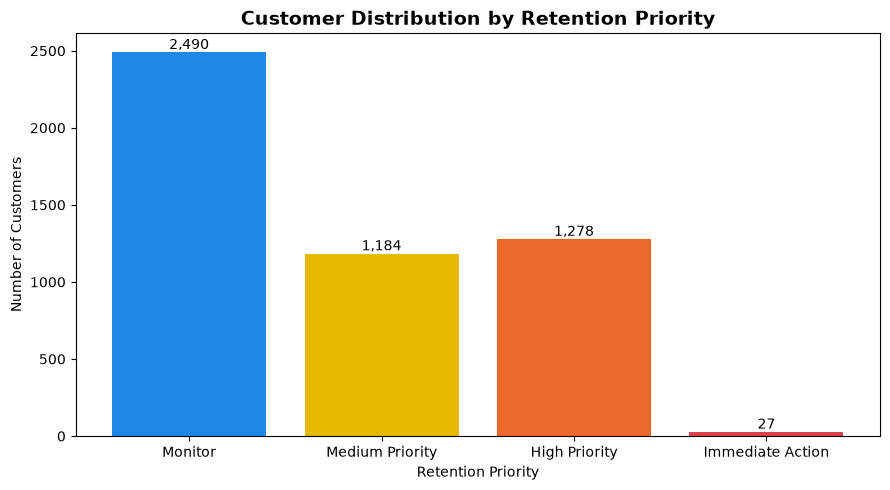

Saved: reports/figures/03_retention_priority_distribution.png


In [2]:
# Figure 3: Retention Priority Distribution

retention_order = [
    "Monitor",
    "Medium Priority",
    "High Priority",
    "Immediate Action"
]

retention_counts = (
    retention_df["RetentionPriority"]
    .value_counts()
    .reindex(retention_order)
)

retention_colors = [
    "#1E88E5",  # Monitor - blue
    "#E6B800",  # Medium Priority - yellow
    "#ED6A2C",  # High Priority - orange
    "#D9434E"   # Immediate Action - red
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    retention_counts.index,
    retention_counts.values,
    color=retention_colors
)

plt.title("Customer Distribution by Retention Priority",
          fontsize=14,
          fontweight="bold")
plt.xlabel("Retention Priority")
plt.ylabel("Number of Customers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "03_retention_priority_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: reports/figures/03_retention_priority_distribution.png")